In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import os
import cv2
from PIL import Image

In [2]:
metadata = pd.read_csv("../reports/dataset_metadata.csv")
metadata.head()

,dataset,image_path,file_name,extension
0,ADMS,../data/raw/adms/Valid/images/c_-308-_jpg.rf.0...,c_-308-_jpg.rf.0b71b13d1c0db0ac91b0997247d22a4...,.jpg
1,ADMS,../data/raw/adms/Valid/images/112_jpg.rf.93fc7...,112_jpg.rf.93fc71b2c98ad78087aaf17c7778f857.jpg,.jpg
2,ADMS,../data/raw/adms/Valid/images/CHANNEL_03_20220...,CHANNEL_03_20220509152715_20220509152725_mp4-8...,.jpg
3,ADMS,../data/raw/adms/Valid/images/358_jpg.rf.0bc5f...,358_jpg.rf.0bc5fd26b9209862fe5336d1cacb2ed8.jpg,.jpg
4,ADMS,../data/raw/adms/Valid/images/_-3-_mp4-96_jpg....,_-3-_mp4-96_jpg.rf.5a65ec89c93eaf85c76b0530bda...,.jpg


In [3]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 36307 entries, 0 to 36306
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   dataset     36307 non-null  str  
 1   image_path  36307 non-null  str  
 2   file_name   36307 non-null  str  
 3   extension   36307 non-null  str  
dtypes: str(4)
memory usage: 1.1 MB


In [4]:
metadata.describe(include="all")

,dataset,image_path,file_name,extension
count,36307,36307,36307,36307
unique,3,36307,36307,2
top,StateFarm,../data/raw/adms/Valid/images/c_-308-_jpg.rf.0...,c_-308-_jpg.rf.0b71b13d1c0db0ac91b0997247d22a4...,.jpg
freq,22423,1,1,32307


In [5]:
metadata.isnull().sum()

dataset       0
image_path    0
file_name     0
extension     0
dtype: int64

In [6]:
missing = metadata.isnull().sum().to_frame("Missing Values").T
display(missing)

,dataset,image_path,file_name,extension
Missing Values,0,0,0,0


In [7]:
metadata.duplicated().sum()

np.int64(0)

In [8]:
def validate_image(path):
    try:
        img = Image.open(path)
        img.verify()
        return True
    except:
        return False

In [9]:
metadata["valid_image"] = metadata["image_path"].apply(validate_image)

In [10]:
metadata["valid_image"].value_counts()

valid_image
True    36307
Name: count, dtype: int64

In [11]:
metadata = metadata[
    metadata["valid_image"] == True
].copy()

In [12]:
duplicates = metadata.duplicated().sum()
print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


In [13]:
def file_size(path):
    return os.path.getsize(path)/(1024*1024)

In [14]:
metadata["size_mb"] = metadata.image_path.apply(file_size)

<Axes: >

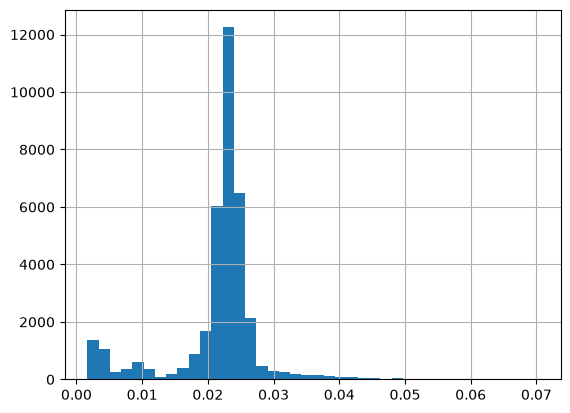

In [15]:
import matplotlib as plt
metadata["size_mb"].hist(bins=40)

In [16]:
def resolution(path):
    img = Image.open(path)
    return img.size

In [17]:
metadata["resolution"] = metadata.image_path.apply(resolution)

In [18]:
metadata["width"] = metadata.resolution.apply(lambda x:x[0])
metadata["height"] = metadata.resolution.apply(lambda x:x[1])

In [19]:
metadata[["width","height"]].describe().T

,count,mean,std,min,25%,50%,75%,max
width,36307.0,380.025202,166.49870,60.0,320.0,320.0,640.0,640.0
height,36307.0,281.376677,122.04727,60.0,240.0,240.0,360.0,640.0


In [20]:
metadata["aspect_ratio"] = metadata.width/metadata.height

In [21]:
metadata.groupby("dataset").size()

dataset
ADMS           9884
Drowsiness     4000
StateFarm     22423
dtype: int64

In [22]:
metadata.to_csv(
    "../data/processed/master_metadata.csv",
    index=False
)

In [23]:
metadata.image_path.iloc[0]

'../data/raw/adms/Valid/images/c_-308-_jpg.rf.0b71b13d1c0db0ac91b0997247d22a4f.jpg'

In [24]:
from collections import Counter
extensions = Counter([img.suffix.lower() for img in metadata.image_path.map(Path)])
print(extensions)

Counter({'.jpg': 32307, '.png': 4000})


In [25]:
cleaning_log = pd.DataFrame({
    "Issue":[
        "Missing Values",
        "Duplicate Records",
        "Invalid Images"
    ],
    "Count":[
        missing.sum().values[0],
        duplicates,
        (~metadata["valid_image"]).sum()
    ],
    "Treatment":[
        "No Action",
        "Removed",
        "Removed"
    ]
})

cleaning_log

,Issue,Count,Treatment
0,Missing Values,0,No Action
1,Duplicate Records,0,Removed
2,Invalid Images,0,Removed


In [26]:
metadata.to_csv(
    "../data/processed/master_metadata.csv",
    index=False
)
cleaning_log.to_csv(
    "../reports/data_cleaning_log.csv",
    index=False
)
print("✔ master_metadata.csv created")
print("✔ data_cleaning_log.csv created")

✔ master_metadata.csv created
✔ data_cleaning_log.csv created


In [27]:
print("=" * 50)
print("DATA CLEANING SUMMARY")
print("=" * 50)

print(f"Total Images : {len(metadata)}")
print(f"Datasets     : {metadata['dataset'].nunique()}")
print(f"Extensions   : {metadata['extension'].nunique()}")

print("\nNotebook 2 Complete ✔")

DATA CLEANING SUMMARY
Total Images : 36307
Datasets     : 3
Extensions   : 2

Notebook 2 Complete ✔


#### Key Observations

- Observation 1
The metadata table was successfully consolidated from three public Driver Monitoring System datasets.
- Observation 2
Duplicate metadata records were identified and removed where applicable.
- Observation 3
Image validation confirmed that only readable image files were retained for further analysis.
- Observation 4
Image dimensions and aspect ratios were computed to support downstream exploratory data analysis and feature engineering.
#### Research Implication
The cleaned metadata table provides a unified and validated source for all subsequent analyses, ensuring reproducibility and consistent preprocessing across the integrated datasets.